<a href="https://colab.research.google.com/github/acaicomdados/analise-reservatorios-federais/blob/main/An%C3%A1lise%20feito%20nos%20encontros/An%C3%A1lise%20s%C3%A9rie%20hist%C3%B3rica/Bacia%20Tocantins/An%C3%A1lise_serie_historica_tocantis_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análise série histórica da bacia de Tocantins

Neste notebook será feito a continuação da análise do Tocantins, do que foi feito no útimo encontro e vamos entrar mais a profundo sobre a análise

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from statsmodels.tsa.seasonal import seasonal_decompose

In [2]:
url = 'https://raw.githubusercontent.com/acaicomdados/analise-reservatorios-federais/main/Datasets/S%C3%A9rie%20hist%C3%B3rica/Tocantins/serie_historica_tocantins.csv'

serie_tocantins = pd.read_csv(url)
serie_tocantins.drop('Unnamed: 0',axis=1,inplace=True)
serie_tocantins.head()

,data,id_reservatorio,nome_reservatorio,afluencia,bacia,rio,estado_sigla,ano,mes
0,2000-01-01,19128,SERRA DA MESA,1570.00,TOCANTINS,TOCANTINS,GO,2000,1
1,2000-01-02,19128,SERRA DA MESA,2070.94,TOCANTINS,TOCANTINS,GO,2000,1
2,2000-01-03,19128,SERRA DA MESA,2927.00,TOCANTINS,TOCANTINS,GO,2000,1
3,2000-01-06,19128,SERRA DA MESA,2379.00,TOCANTINS,TOCANTINS,GO,2000,1
4,2000-01-09,19128,SERRA DA MESA,3050.00,TOCANTINS,TOCANTINS,GO,2000,1


In [3]:
serie_tocantins.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54320 entries, 0 to 54319
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   data               54320 non-null  object 
 1   id_reservatorio    54320 non-null  int64  
 2   nome_reservatorio  54320 non-null  object 
 3   afluencia          54291 non-null  float64
 4   bacia              54320 non-null  object 
 5   rio                54320 non-null  object 
 6   estado_sigla       54320 non-null  object 
 7   ano                54320 non-null  int64  
 8   mes                54320 non-null  int64  
dtypes: float64(1), int64(3), object(5)
memory usage: 3.7+ MB


In [4]:
serie_tocantins['data'] = pd.to_datetime(serie_tocantins['data'])
serie_tocantins.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54320 entries, 0 to 54319
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   data               54320 non-null  datetime64[ns]
 1   id_reservatorio    54320 non-null  int64         
 2   nome_reservatorio  54320 non-null  object        
 3   afluencia          54291 non-null  float64       
 4   bacia              54320 non-null  object        
 5   rio                54320 non-null  object        
 6   estado_sigla       54320 non-null  object        
 7   ano                54320 non-null  int64         
 8   mes                54320 non-null  int64         
dtypes: datetime64[ns](1), float64(1), int64(3), object(4)
memory usage: 3.7+ MB


In [5]:
serie_tocantins.head()

,data,id_reservatorio,nome_reservatorio,afluencia,bacia,rio,estado_sigla,ano,mes
0,2000-01-01,19128,SERRA DA MESA,1570.00,TOCANTINS,TOCANTINS,GO,2000,1
1,2000-01-02,19128,SERRA DA MESA,2070.94,TOCANTINS,TOCANTINS,GO,2000,1
2,2000-01-03,19128,SERRA DA MESA,2927.00,TOCANTINS,TOCANTINS,GO,2000,1
3,2000-01-06,19128,SERRA DA MESA,2379.00,TOCANTINS,TOCANTINS,GO,2000,1
4,2000-01-09,19128,SERRA DA MESA,3050.00,TOCANTINS,TOCANTINS,GO,2000,1


In [6]:
serie_tocantins['nome_reservatorio'].unique()

array(['SERRA DA MESA', 'CANA BRAVA', 'SAO SALVADOR', 'PEIXE ANGICAL',
       'LAJEADO', 'ESTREITO', 'TUCURUI'], dtype=object)

Para facilitar, iremos analisar alguma usina separadamente e fazer as anlise, iremos começar pela usina de Tucurui qu é uma das mais importantes para o Estado do Pará

In [7]:
tucurui = serie_tocantins[serie_tocantins['nome_reservatorio']=='TUCURUI']
tucurui.reset_index(drop=True,inplace=True)
tucurui.head()

,data,id_reservatorio,nome_reservatorio,afluencia,bacia,rio,estado_sigla,ano,mes
0,2000-01-01,19134,TUCURUI,18440.76,TOCANTINS,TOCANTINS,PA,2000,1
1,2000-01-02,19134,TUCURUI,20274.31,TOCANTINS,TOCANTINS,PA,2000,1
2,2000-01-03,19134,TUCURUI,21396.60,TOCANTINS,TOCANTINS,PA,2000,1
3,2000-01-06,19134,TUCURUI,20935.29,TOCANTINS,TOCANTINS,PA,2000,1
4,2000-01-08,19134,TUCURUI,22158.10,TOCANTINS,TOCANTINS,PA,2000,1


In [8]:
tucurui['afluencia']= np.where(tucurui['afluencia']<0,tucurui['afluencia']*(-1),tucurui['afluencia'])
# correção de um valor que deva ter sidoi colocado um valor negativo por engano

<ipython-input-8-c51a99389219>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tucurui['afluencia']= np.where(tucurui['afluencia']<0,tucurui['afluencia']*(-1),tucurui['afluencia'])


Text(0, 0.5, 'Afluencia (m3/s)')

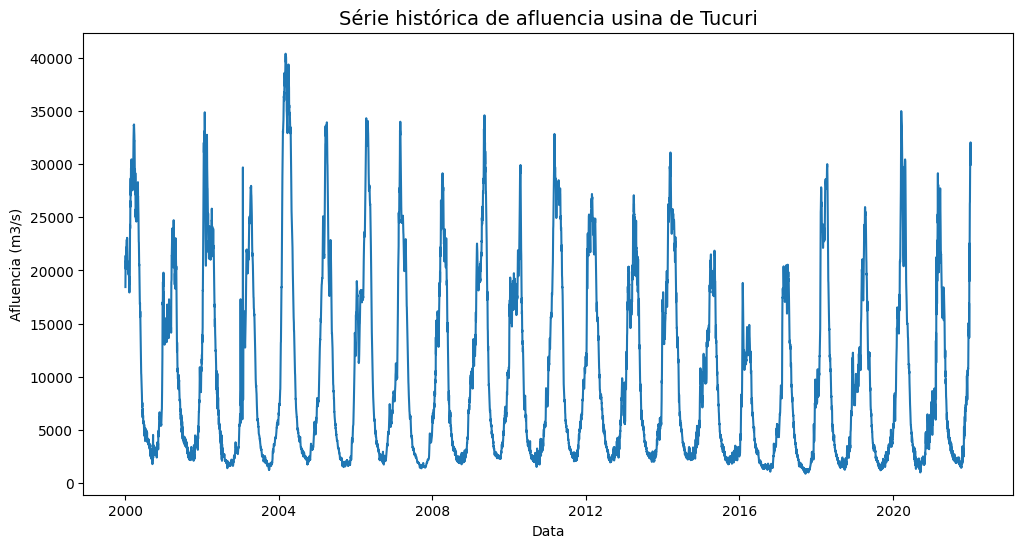

In [9]:
plt.figure(figsize=(12,6))
plt.title('Série histórica de afluencia usina de Tucuri',fontsize=14)
sns.lineplot(data=tucurui,x='data',y='afluencia')
plt.xlabel('Data')
plt.ylabel('Afluencia (m3/s)')

In [12]:
tucurui.drop(['id_reservatorio','nome_reservatorio','bacia','rio','estado_sigla'],
             axis=1,inplace=True)
tucurui.head()

<ipython-input-12-12d18e52187d>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tucurui.drop(['id_reservatorio','nome_reservatorio','bacia','rio','estado_sigla'],


,afluencia,ano,mes
data,,,
2000-01-01,18440.76,2000,1
2000-01-02,20274.31,2000,1
2000-01-03,21396.60,2000,1
2000-01-06,20935.29,2000,1
2000-01-08,22158.10,2000,1


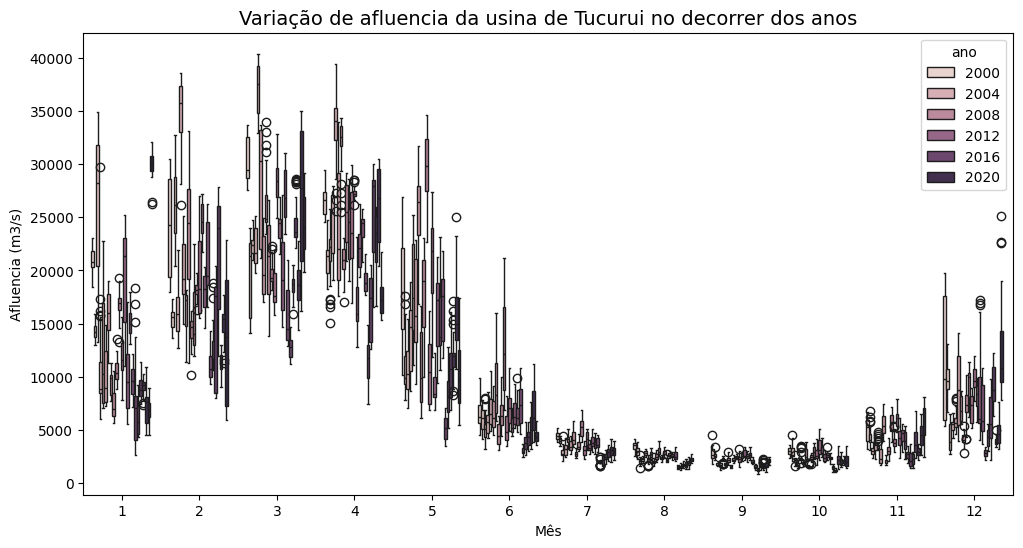

In [15]:
plt.figure(figsize=(12,6))
plt.title('Variação de afluencia da usina de Tucurui no decorrer dos anos',fontsize=14)
sns.boxplot(data=tucurui,x='mes',y='afluencia',hue='ano')
plt.xlabel('Mês')
plt.ylabel('Afluencia (m3/s)');

Pode observar um periodo de cheia, principalmente nos periodos de março e abril , e um periodo de estiagem de julho a outubro (eria essa a sazonalidade)

Ou seja:

- De janeiro a abril tem uma tendencia de subida
- De maio até outubro, uma tendencia de queda e novembro uma subida

Isso pode ser visto aplicando a média movel de 30 dias no grafico abaixo


In [21]:
px.line(tucurui,x=tucurui.index,y=tucurui['afluencia'].rolling(window=30).mean(),
        title='Média móvel de 30 dias da afluencia da usina de Tucurui',
        labels={'y':'Afluencia (m3/s)','data':'Data'})

/usr/local/lib/python3.10/dist-packages/_plotly_utils/basevalidators.py:105: FutureWarning:

The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result



A partir disso, podemos criar duas hipoteses

- uma vazão maior se relaciona também uma periodo maior de chuva
- esse processo se repete com periodo de geração de energia

Essas hispotesse podem ser analisadas em um futuro com dados de pluviometria e de geração de energia

Text(0, 0.5, 'Afluencia (m3/s)')

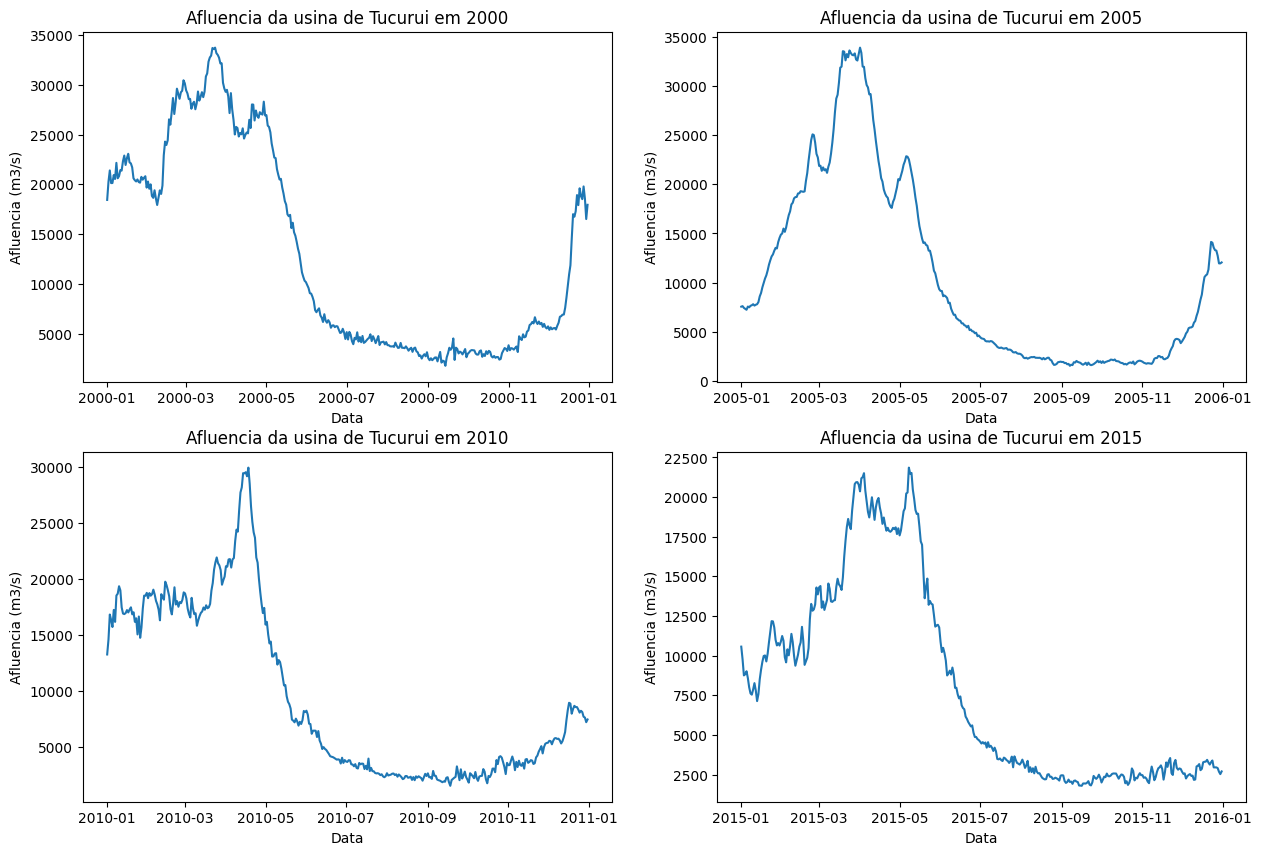

In [30]:
fig, axs = plt.subplots(2, 2, figsize=(15, 10))

ano_2000 = sns.lineplot(x=tucurui[tucurui['ano']==2000].index,y='afluencia',data=tucurui[tucurui['ano']==2000],
             ax=axs[0, 0])
ano_2000.set_title('Afluencia da usina de Tucurui em 2000')
ano_2000.set_xlabel('Data')
ano_2000.set_ylabel('Afluencia (m3/s)')

ano_2005 = sns.lineplot(x=tucurui[tucurui['ano']==2005].index,y='afluencia',data=tucurui[tucurui['ano']==2005],
             ax=axs[0, 1])
ano_2005.set_title('Afluencia da usina de Tucurui em 2005')
ano_2005.set_xlabel('Data')
ano_2005.set_ylabel('Afluencia (m3/s)')

ano_2010 = sns.lineplot(x=tucurui[tucurui['ano']==2010].index,y='afluencia',data=tucurui[tucurui['ano']==2010],
             ax=axs[1, 0])
ano_2010.set_title('Afluencia da usina de Tucurui em 2010')
ano_2010.set_xlabel('Data')
ano_2010.set_ylabel('Afluencia (m3/s)')

ano_2015 = sns.lineplot(x=tucurui[tucurui['ano']==2015].index,y='afluencia',data=tucurui[tucurui['ano']==2015],
             ax=axs[1, 1])
ano_2015.set_title('Afluencia da usina de Tucurui em 2015')
ano_2015.set_xlabel('Data')
ano_2015.set_ylabel('Afluencia (m3/s)')

Pode se observar que o periodo de março e abril é quando se tem a maiores cheis